# Vergleich: Normales vs. Neues MixUp-Verfahren

Dieses Notebook vergleicht das normale (standardmäßige) MixUp-Verfahren mit unserer neuen (gleichverteilten) Methode.

Beide Methoden schneiden **zusammenhängende Blöcke** aus den Texten aus und mischen sie. Der einzige Unterschied liegt darin, wie die Blockgrößen (und damit das Target) bestimmt werden:

1. **Normal:**
   * Schneidet zufällige Start/End-Bereiche aus beiden Texten völlig unabhängig aus.
   * Das Target wird über das Verhältnis der Zeichenanzahl berechnet.
2. **Neu (Gleichverteilt):**
   * Zieht zuerst ein gleichverteiltes Target $\lambda \sim U(0.0, 1.0)$ vorab.
   * Berechnet die exakte Anzahl benötigter Sätze ($num\_ls$ und $num\_as$) für eine dynamische Gesamtgröße $N$ (zwischen 8 und 15 Sätzen).
   * Schneidet zusammenhängende Blöcke dieser Längen aus den Artikeln aus.

In [37]:
import pandas as pd
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os

# Configuration
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8
MAX_SIM = 0.98

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Daten laden und Spacy-Sentencizer vorbereiten

In [38]:
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])
print(f"Gefundene Artikelpaare: {len(df_filtered)}")

# Spacy für schnelles Satz-Splitting (Sentencizer) vorbereiten
nlp = spacy.blank("de")
nlp.add_pipe("sentencizer")

Gefundene Artikelpaare: 1032


## 2. Hilfsfunktion für zusammenhängende Slices

In [39]:
def get_contiguous_slice(sentences, k):
    """Schneidet einen zusammenhängenden Block von k Sätzen aus.
    Falls der Text zu kurz ist, wird er ganz zurückgegeben."""
    num_sents = len(sentences)
    if num_sents == 0 or k <= 0:
        return []
    if num_sents <= k:
        return list(sentences)
    else:
        start = random.randint(0, num_sents - k)
        return sentences[start : start + k]

## 3. Dataset Klassen definieren

In [40]:
class NormalMixupDataset(Dataset):
    def __init__(self, df, nlp_sentencizer):
        self.ls_data = []
        self.as_data = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere (Normal)"):
            ls_sents = [s.text.strip() for s in nlp_sentencizer(str(row["ls_text"])).sents if s.text.strip()]
            as_sents = [s.text.strip() for s in nlp_sentencizer(str(row["as_text"])).sents if s.text.strip()]
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
    def __len__(self):
        return len(self.ls_data)
        
    def __getitem__(self, idx):
        leichte_saetze = self.ls_data[idx]
        alltags_saetze = self.as_data[idx]
        
        num_leicht = len(leichte_saetze)
        num_alltag = len(alltags_saetze)
        
        if num_leicht == 0 or num_alltag == 0:
            return "", 0.5
            
        start_leichte_saetze, ende_leichte_saetze = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
        sample_leicht = leichte_saetze[start_leichte_saetze:ende_leichte_saetze]
        
        start_alltags_saetze, ende_alltags_saetze = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
        sample_alltag = alltags_saetze[start_alltags_saetze:ende_alltags_saetze]
        
        kompletter_absatz = sample_leicht + sample_alltag
        random.shuffle(kompletter_absatz)
        
        str_sample_leicht = ''.join(sample_leicht)
        str_sample_alltag = ''.join(sample_alltag)
        len_sample_leicht = len(str_sample_leicht)
        len_sample_alltag = len(str_sample_alltag)
        
        total_len = len_sample_leicht + len_sample_alltag
        regression_target = len_sample_leicht / total_len if total_len > 0 else 0.5
        
        return ' '.join(kompletter_absatz), regression_target


class NewMixupDataset(Dataset):
    def __init__(self, df, nlp_sentencizer):
        self.ls_data = []
        self.as_data = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere (Neu/Uniform)"):
            ls_sents = [s.text.strip() for s in nlp_sentencizer(str(row["ls_text"])).sents if s.text.strip()]
            as_sents = [s.text.strip() for s in nlp_sentencizer(str(row["as_text"])).sents if s.text.strip()]
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
    def __len__(self):
        return len(self.ls_data)
        
    def __getitem__(self, idx):
        leichte_saetze = self.ls_data[idx]
        alltags_saetze = self.as_data[idx]
        
        num_leicht = len(leichte_saetze)
        num_alltag = len(alltags_saetze)
        
        if num_leicht == 0 or num_alltag == 0:
            return "", 0.5
            
        # 1. Ziehe ein stufenloses Lambda aus einer Gleichverteilung
        lam = random.uniform(0.0, 1.0)
        
        # 2. Definiere Ziel-Satzanzahl (z. B. N zufällig zwischen 8 und 15 Sätzen)
        N = 20
        num_ls = int(round(lam * N))
        num_as = N - num_ls
        
        # 3. Zusammenhängende Slices mit berechneter Länge ziehen
        sample_leicht = get_contiguous_slice(leichte_saetze, num_ls)
        sample_alltag = get_contiguous_slice(alltags_saetze, num_as)
        
        # 4. Zusammenfügen und mischen
        kompletter_absatz = sample_leicht + sample_alltag
        random.shuffle(kompletter_absatz)
        
        # 5. Target als tatsächliches Satzverhältnis berechnen
        total_sents = len(sample_leicht) + len(sample_alltag)
        regression_target = len(sample_leicht) / total_sents if total_sents > 0 else 0.5
        
        return ' '.join(kompletter_absatz), regression_target

## 4. Simulation & Target-Erfassung

In [41]:
normal_ds = NormalMixupDataset(df_filtered, nlp)
new_ds = NewMixupDataset(df_filtered, nlp)

normal_targets = []
new_targets = []

EPOCHS = 10
for epoch in range(EPOCHS):
    for i in range(len(df_filtered)):
        _, t_norm = normal_ds[i]
        _, t_new = new_ds[i]
        
        normal_targets.append(t_norm)
        new_targets.append(t_new)

print(f"Simulation beendet. {len(normal_targets)} Samples generiert.")

Segmentiere (Normal):   0%|          | 0/1032 [00:00<?, ?it/s]

Segmentiere (Neu/Uniform):   0%|          | 0/1032 [00:00<?, ?it/s]

Simulation beendet. 10320 Samples generiert.


## 5. Visualisierung & Vergleich

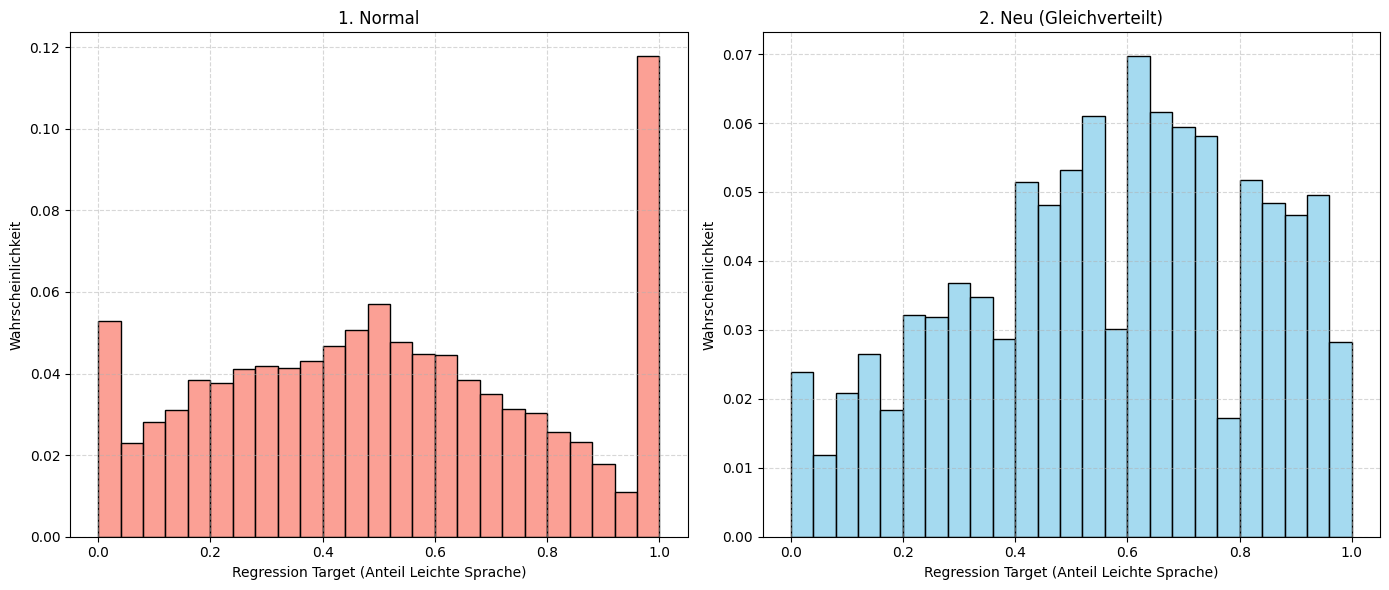

In [45]:
plt.figure(figsize=(14, 6))

# 1. Normal
plt.subplot(1, 2, 1)
sns.histplot(normal_targets, bins=25, color="salmon", stat="probability")
plt.title("1. Normal")
plt.xlabel("Regression Target (Anteil Leichte Sprache)")
plt.ylabel("Wahrscheinlichkeit")
plt.xlim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)

# 2. Neu (Gleichverteilt)
plt.subplot(1, 2, 2)
sns.histplot(new_targets, bins=25, color="skyblue", stat="probability")
plt.title("2. Neu (Gleichverteilt)")
plt.xlabel("Regression Target (Anteil Leichte Sprache)")
plt.ylabel("Wahrscheinlichkeit")
plt.xlim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../results/mixup_comparison_two_variants.png", dpi=300)
plt.show()